# Test technique NLP - Classification de retours citoyens sur les services publics

## Contexte du projet

Ce notebook est réalisé dans le cadre du test technique de sélection des participants de la **Togo AI Summer School 2026**, pour une candidature à un stage Data Science orienté NLP chez **Afriklang**. L'objectif est de construire un pipeline complet de classification de commentaires citoyens portant sur les services publics.

Le jeu de données contient 150 commentaires, répartis en trois catégories équilibrées :

- **Satisfaction** : retours positifs sur un service ;
- **Insatisfaction** : plaintes ou expériences négatives ;
- **Suggestion** : propositions d'amélioration.

Les commentaires sont majoritairement rédigés en français, avec des insertions occasionnelles de termes en éwé ou en mina. Cette caractéristique rend le prétraitement particulièrement important : il faut réduire le bruit tout en évitant de supprimer des informations utiles au sens du commentaire.

## Questions auxquelles l'analyse doit répondre

- Le dataset est-il correctement structuré et équilibré entre les trois catégories ?
- Quelles sont les caractéristiques des textes : longueur, vocabulaire et termes fréquents ?
- Quelle stratégie de nettoyage permet de traiter les nombres, la ponctuation et les termes éwé/mina ?
- Quelle est la vectorisation adaptée à appliquer à ce petit corpus de textes courts ?
- Quel modèle obtient les meilleurs résultats parmi Naïve Bayes, SVM linéaire et Random Forest ?
- Les performances sont-elles équilibrées entre les catégories, notamment selon le F1-score macro ?
- Quelles catégories sont les plus souvent confondues et pourquoi ?

## Plan de travail

1. **Explorer les données** : contrôler la structure, les catégories, l'équilibre des classes et la longueur des commentaires ;
2. **Prétraiter les textes** : normaliser les chaînes, gérer les termes connus en éwé/mina, retirer les stopwords français et lemmatiser ;
3. **Analyser le vocabulaire** : produire des nuages de mots et relever les quinze termes les plus fréquents par catégorie ;
4. **Construire la représentation numérique** : séparer les données en 80 % d'entraînement et 20 % de test, puis appliquer la vectorisation ;
5. **Comparer trois modèles** : entraîner Naïve Bayes, SVM linéaire et Random Forest ;
6. **Évaluer et interpréter** : comparer accuracy et F1-score macro, lire les matrices de confusion, discuter les erreurs, les limites et les améliorations possibles.

Les résultats doivent être interprétés avec prudence : le dataset est de petite taille et les performances mesurées sur un seul split train/test ne suffisent pas à garantir le comportement du modèle sur de nouveaux commentaires.

## Partie 1 - Exploration et prétraitement des données

Cette partie répond au premier volet du sujet : comprendre le dataset avant d'entraîner un modèle et transformer les commentaires bruts en une représentation linguistique exploitable. L'exploration vérifie notamment les dimensions annoncées, l'équilibre entre **Satisfaction**, **Insatisfaction** et **Suggestion**, ainsi que les différences de longueur et de vocabulaire.

Le prétraitement doit respecter deux contraintes. Il doit retirer les éléments peu informatifs pour les modèles statistiques, mais il doit aussi préserver les indices de sentiment et les expressions locales susceptibles de distinguer une plainte, une appréciation ou une suggestion.

### Préparation de l'environnement

Nous allons charger les bibliothèques de manipulation des données, de visualisation, de traitement linguistique et de classification. Nous allons également télécharger les stopwords français et charger le modèle SpaCy `fr_core_news_md`, utilisé ensuite pour la lemmatisation et le filtrage des tokens.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


import regex as re


import nltk
nltk.download("stopwords", quiet=True)
print("NLTK prêt !")
from nltk.corpus import stopwords


!python -m spacy download fr_core_news_md --quiet
import spacy
nlp= spacy.load('fr_core_news_md')
print('SpaCy prêt — modèle :', nlp.meta['name'])


from collections import Counter
from wordcloud import WordCloud


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


import warnings
warnings.filterwarnings('ignore')


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print("Tout est prêt !")

NLTK prêt !
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')
SpaCy prêt — modèle : core_news_md
Tout est prêt !


### Résultat de l'initialisation

L'environnement a été initialisé avec succès : NLTK est prêt, le modèle SpaCy `core_news_md` est chargé et les paramètres d'affichage sont configurés. Le traitement repose donc sur un modèle principalement français ; les éventuels termes éwé ou mina devront être vérifiés dans les étapes suivantes.

### A. Exploration du jeu de données

Cette étape répond à la demande de chargement et d'aperçu : dimensions, colonnes, types, exemples globaux et exemples par catégorie. Elle permet de vérifier que `id` identifie les commentaires, que `texte` contient la variable explicative et que `categorie` correspond bien à la cible à prédire.

Les contrôles visuels servent également à repérer les risques qui peuvent affecter la suite : classes déséquilibrées, textes très courts, textes atypiquement longs, valeurs manquantes ou vocabulaire partagé entre plusieurs catégories.

In [39]:
#Chargement du dataset
print("Chargement du dataset...")
data= pd.read_csv("../data/dataset_nlp_test_tal.csv")
print("Chargement terminé !")

print()

#Structure du dataset : shape, colonnes, types, exemples
print(f"Shape du dataset : {data.shape[0]} lignes x {data.shape[1]} colonnes")
print()

print(f"Colonnes du dataset : {data.columns.to_list()}")
print()

print("Types des colonnes :")
types= data.dtypes
for col in data.columns:
    print(f"\t- {col} : {types[col]}")

print()

print("Aperçu de 15 lignes aléatoires")
display(data.sample(15))

Chargement du dataset...
Chargement terminé !

Shape du dataset : 150 lignes x 3 colonnes

Colonnes du dataset : ['id', 'texte', 'categorie']

Types des colonnes :
	- id : int64
	- texte : str
	- categorie : str

Aperçu de 15 lignes aléatoires


,id,texte,categorie
50,51,Des agents mobiles pourraient servir les zones rurales éloignées.,Suggestion
105,106,La salle d'attente est propre et bien organisée.,Satisfaction
75,76,Il serait utile de créer un label qualité pour les services performants.,Suggestion
54,55,Publier régulièrement des statistiques sur les délais de traitement.,Suggestion
110,111,Prévoir une ligne téléphonique distincte pour les urgences administratives.,Suggestion
104,105,"Formulaire papier illisible, photocopie de mauvaise qualité.",Insatisfaction
60,61,Le nouveau système en ligne facilite vraiment les démarches.,Satisfaction
149,150,Ma réclamation a été prise en charge rapidement.,Satisfaction
49,50,Je n'ai reçu aucun accusé de réception de ma demande.,Insatisfaction
85,86,Je regrette de n'avoir aucune autre option que ce service.,Insatisfaction


#### Résultats du contrôle initial

Le dataset contient **150 lignes et 3 colonnes** : `id`, `texte` et `categorie`. Les trois colonnes sont correctement typées respectivement en entier et en chaînes de caractères, ce qui confirme que le format attendu est respecté.

La sortie montre des commentaires variés : certains sont très courts, tandis que d'autres contiennent plusieurs propositions ou précisions. Les exemples incluent aussi des formulations liées aux langues locales, comme « Akpe na wò », ce qui confirme la nécessité de surveiller le comportement du prétraitement multilingue.

#### Préparation de la comparaison par catégorie

Nous allons maintenant afficher un échantillon de chaque catégorie afin de vérifier que les étiquettes correspondent bien au contenu des commentaires et d'identifier les formulations positives, négatives ou prescriptives.

In [40]:
print("="*25)
print("Exemples par catégorie")
print("="*25)

print()

TARGET= "categorie"

UNIQUES= data["categorie"].unique()
for unique in UNIQUES:
    print(f"- Catégorie {unique}")
    display(data[data[TARGET] == unique].sample(10))

Exemples par catégorie

- Catégorie Insatisfaction


,id,texte,categorie
11,12,Traitement discriminatoire selon la tête du client.,Insatisfaction
123,124,"Mauvaise gestion de la foule, risque de bousculade.",Insatisfaction
52,53,"Manque de personnel visible, seulement 2 guichets ouverts sur 8.",Insatisfaction
18,19,On m'a remis un document avec des fautes dans mon nom.,Insatisfaction
49,50,Je n'ai reçu aucun accusé de réception de ma demande.,Insatisfaction
136,137,Le système informatique est constamment en panne.,Insatisfaction
0,1,Manque total de communication entre les services.,Insatisfaction
122,123,On m'a demandé des pièces non mentionnées sur le site officiel.,Insatisfaction
29,30,Le délai légal n'est pas respecté et personne n'en rend compte.,Insatisfaction
45,46,Agents absents la moitié du temps sans remplacement prévu.,Insatisfaction


- Catégorie Suggestion


,id,texte,categorie
100,101,Il serait bien d'avoir une version du site en langue locale.,Suggestion
68,69,Une signalétique claire dans les locaux éviterait beaucoup de confusion.,Suggestion
33,34,Créer une plateforme de signalement anonyme pour les dysfonctionnements.,Suggestion
106,107,Des bornes interactives dans les mairies faciliteraient les démarches.,Suggestion
50,51,Des agents mobiles pourraient servir les zones rurales éloignées.,Suggestion
13,14,Numériser les archives pour retrouver rapidement les anciens dossiers.,Suggestion
75,76,Il serait utile de créer un label qualité pour les services performants.,Suggestion
80,81,Des formations régulières du personnel amélioreraient la qualité du service.,Suggestion
129,130,Former les agents à l'accueil bienveillant et à la gestion du stress.,Suggestion
35,36,Allonger les horaires d'ouverture pour inclure les samedis matin.,Suggestion


- Catégorie Satisfaction


,id,texte,categorie
55,56,"Les infrastructures ont été bien améliorées, bravo aux équipes.",Satisfaction
70,71,"Je suis content du résultat, dossier traité sans complications.",Satisfaction
26,27,"Personnel compétent et sympathique, je suis très satisfait.",Satisfaction
148,149,"Le guichet unique fonctionne très bien, gain de temps considérable.",Satisfaction
64,65,"Service honnête et transparent, merci.",Satisfaction
12,13,Le service a été rapide et le personnel très accueillant.,Satisfaction
62,63,Le formulaire en ligne est intuitif et facile à remplir.,Satisfaction
137,138,"Bonne initiative, le digital simplifie nos démarches quotidiennes.",Satisfaction
111,112,Mon problème a été résolu en une seule visite.,Satisfaction
138,139,"Akpe na wò, service très professionnel et efficace.",Satisfaction


#### Résultats des exemples par catégorie

Les exemples confirment la cohérence sémantique des étiquettes : les commentaires d'Insatisfaction décrivent notamment des délais, des pannes, un manque de personnel ou l'absence de réponse ; les Suggestions proposent des actions comme créer une plateforme, former les agents ou étendre les horaires ; les commentaires de Satisfaction mentionnent un service rapide, professionnel ou efficace.

Cette séparation n'est toutefois pas uniquement lexicale. Des termes comme « service », « dossier », « traitement » ou « ligne » apparaissent dans plusieurs catégories ; ils risquent donc d'être peu discriminants seuls.

#### Analyse des volumes et des longueurs

Nous allons mesurer la répartition des classes et calculer la longueur moyenne des commentaires par catégorie. L'objectif est de vérifier l'équilibre annoncé par le sujet et de déterminer si la longueur peut constituer un signal descriptif.

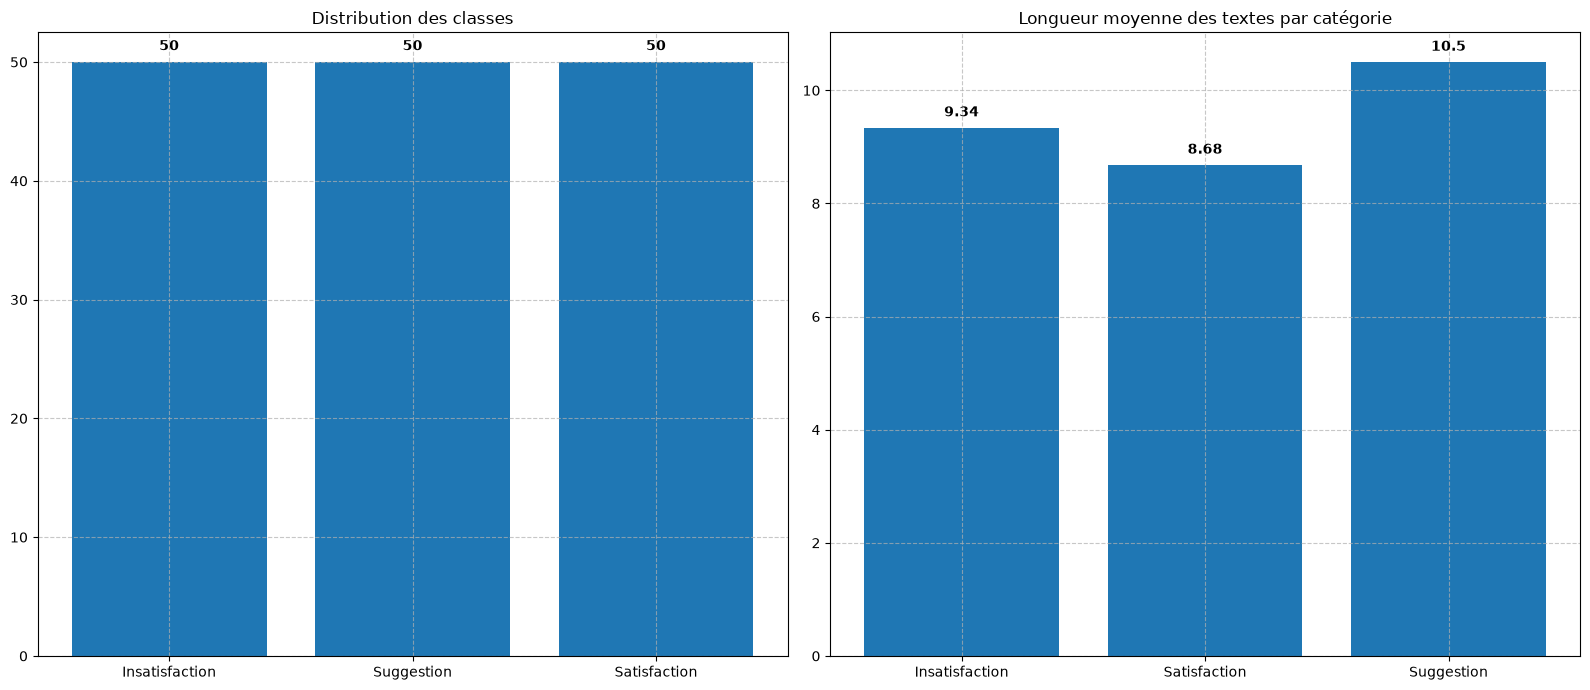

In [41]:
fig1, ax1= plt.subplots(1, 2, figsize=(16, 7))

counts= data[TARGET].value_counts()
ax1[0].bar(counts.index, counts.values)
for i, v in enumerate(counts.values):
    ax1[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
ax1[0].grid(True, linestyle="--", axis="both", alpha=0.7)
ax1[0].set_title("Distribution des classes")

lengths= pd.DataFrame({"length": data["texte"].apply(lambda x: len(x.split())), 
                       "categorie": data[TARGET]})
len_avgs= lengths.groupby(TARGET).agg(len_avg=("length", "mean"))["len_avg"]
ax1[1].bar(len_avgs.index, len_avgs.values)
for i, v in enumerate(len_avgs.values):
    ax1[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')
ax1[1].grid(True, linestyle="--", axis="both", alpha=0.7)
ax1[1].set_title("Longueur moyenne des textes par catégorie")


plt.tight_layout()
plt.show()

#### Résultats de la répartition et des longueurs moyennes

Les trois classes sont parfaitement équilibrées avec **50 commentaires chacune**. L'accuracy pourra donc être interprétée sans correction liée à un déséquilibre de classes, même si le F1-score macro reste nécessaire pour repérer les écarts de rappel.

La longueur moyenne est de **9,34 mots pour Insatisfaction**, **8,68 mots pour Satisfaction** et **10,5 mots pour Suggestion**. Les Suggestions sont donc légèrement plus longues en moyenne, mais l'écart reste limité : La longueur seule ne devrait pas suffire à séparer les catégories.

#### Distribution globale des longueurs

Nous allons maintenant observer la dispersion de la longueur des 150 commentaires, puis comparer visuellement les distributions propres à chaque catégorie.

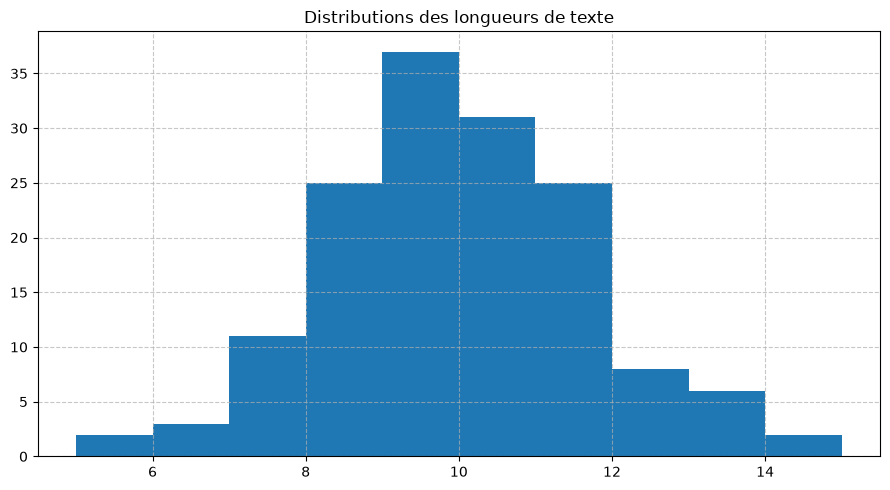

In [42]:
plt.figure(figsize=(9, 5))
plt.hist(lengths["length"], bins=10)
plt.title("Distributions des longueurs de texte")
plt.grid(True, linestyle="--", alpha=0.7, axis="both")
plt.tight_layout()
plt.show()

#### Résultat de la distribution globale

La majorité des commentaires se situe entre **8 et 12 mots**, avec des valeurs observées approximativement de **5 à 15 mots**. Le corpus est donc composé de textes courts, ce qui justifie une représentation fondée sur les termes, mais augmente aussi le risque qu'un commentaire contienne trop peu de contexte pour être classé correctement.

#### Comparaison des distributions par catégorie

Nous allons comparer les histogrammes par catégorie afin de vérifier si les différences de longueur sont réellement séparatrices ou si les distributions se recouvrent largement.

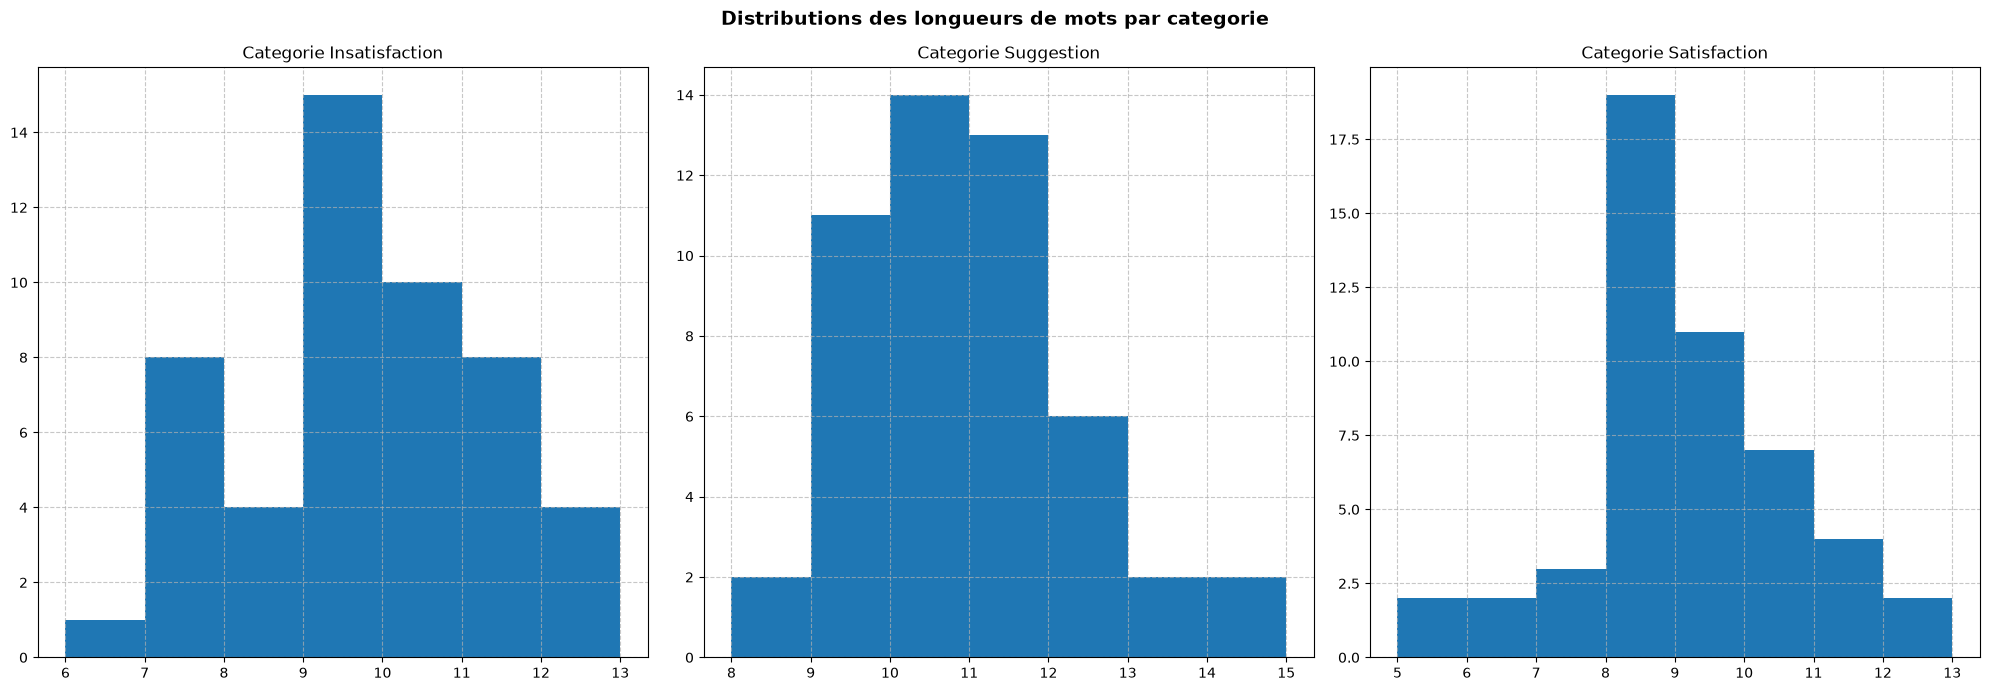

In [43]:
fig1, ax1= plt.subplots(1, 3, figsize=(20, 7))

fig1.suptitle("Distributions des longueurs de mots par categorie", fontweight="bold", fontsize=14)

for i, cat in enumerate(UNIQUES):
    max, min= lengths[lengths[TARGET] == cat]["length"].max(), lengths[lengths[TARGET] == cat]["length"].min()
    ax1[i].hist(lengths[lengths[TARGET] == cat]["length"], bins= max-min)
    ax1[i].set_title(f"Categorie {cat}")
    ax1[i].grid(True, linestyle="--", alpha=0.7, axis="both")

plt.tight_layout()
plt.show()

#### Résultat de la comparaison des longueurs

Les trois distributions se recouvrent principalement autour de **8 à 12 mots**. Suggestion s'étend davantage vers les textes longs, tandis que Satisfaction contient aussi quelques textes très courts ; toutefois, le recouvrement reste important. Cette observation confirme que la classification devra principalement exploiter le vocabulaire et la structure sémantique, et non la longueur seule.

### B. Prétraitement linguistique

Le prétraitement transforme les textes bruts en une représentation plus homogène avant la vectorisation. Il doit supprimer le bruit tout en conservant les mots porteurs de sens pour la tâche de classification.

Les choix retenus sont volontairement simples et traçables : normalisation des chaînes, remplacement des nombres, retrait de la ponctuation, prise en compte de quelques termes locaux connus, suppression des stopwords français et lemmatisation. Cette approche constitue une baseline reproductible, mais elle ne remplace pas une véritable analyse linguistique du français mélangé à l'éwé ou au mina.

#### Construction de la liste de mots vides

Nous allons comparer les stopwords français fournis par NLTK et SpaCy, puis utiliser leur union pour retirer les mots fonctionnels avant la lemmatisation. Les termes locaux ne seront pas ajoutés automatiquement à cette liste, afin de préserver leur éventuelle valeur discriminante.

In [44]:
stop_nltk= set(stopwords.words('french'))
print(f'NLTK  : {len(stop_nltk)} stopwords')

stop_spacy= nlp.Defaults.stop_words
print(f'SpaCy : {len(stop_spacy)} stopwords')

stop_fr= stop_nltk | stop_spacy
print(f'Union NLTK U SpaCy : {len(stop_fr)} stopwords')

NLTK  : 157 stopwords
SpaCy : 507 stopwords
Union NLTK U SpaCy : 579 stopwords


#### Résultats de la construction des stopwords

NLTK fournit **157 stopwords**, SpaCy en fournit **507**, et leur union contient **579 termes**. L'union ajoute donc des formes absentes de l'une des deux ressources tout en évitant de compter deux fois les termes communs.

Ce résultat justifie l'utilisation de l'union pour un corpus majoritairement français. Il faut cependant conserver une vigilance particulière sur les mots éwé et mina, qui ne doivent pas être supprimés uniquement parce qu'ils sont inconnus des ressources françaises.

#### Nettoyage et préparation des tokens

Nous allons maintenant définir les fonctions qui normalisent les textes, remplacent les termes locaux connus, retirent les stopwords et appliquent la lemmatisation SpaCy. La cellule suivante ne produit pas encore de résultat ; Elle prépare le pipeline qui sera appliqué au dataset juste après.

In [8]:
def clean_text(text: str) -> str:
    ""

    MAP={
            r"\bmele\b" : "négatif",
            r"\bo\b": "non",
            r"\bakpe\b": "merci",
            r"\bnyuie\b": "bon"
        }
    
    texte= text.lower()
    texte= re.sub(r"\d+", "[DIGIT]", texte)
    texte= re.sub(r"[^\w\s]", " ", texte)
    texte= re.sub(r"\s+", " ", texte)

    for local_term, fr_trans in MAP.items():
        texte= re.sub(local_term, fr_trans, texte)

    return texte



def text_preprocessing(text : str) -> list[str]:
    ""

    texte= clean_text(text=text)

    tokens= [token for token in texte.split() if token not in stop_fr]

    doc= nlp(" ".join(tokens))

    tokens_clean= []

    for token in doc:
        if token.has_vector or token.pos_ == "PROPN" or token.text== "DIGIT":
            tokens_clean.append(token.lemma_.lower())

    tokens_clean= list(set([t for t in tokens_clean if len(t) > 2]))

    return tokens_clean

#### Résultat de la définition du pipeline

Le pipeline conserve le marqueur `[DIGIT]` et les tokens reconnus par SpaCy ou identifiés comme noms propres. Les termes locaux explicitement mappés sont convertis en équivalents français ; Les autres termes restent présents lorsqu'ils sont conservés comme tokens utiles. Nous allons maintenant appliquer ces fonctions aux 150 commentaires et comparer les colonnes avant et après traitement.

#### Application du prétraitement

Nous allons créer trois représentations complémentaires : le texte nettoyé, la liste des tokens conservés et le texte propre reconstitué. L'échantillon affiché permettra de vérifier concrètement l'effet de la normalisation et de la lemmatisation.

In [45]:
data["texte_nettoye"]= data["texte"].apply(clean_text)
data["tokens"]= data["texte"].apply(text_preprocessing)
data["texte_propre"]= data["tokens"].apply(lambda token: " ".join(token))

data.sample(15)

,id,texte,categorie,texte_nettoye,tokens,texte_propre
23,24,Un accusé de réception automatique rassurerait les usagers.,Suggestion,un accusé de réception automatique rassurerait les usagers,"[accuser, automatique, rassurer, usager, réception]",accuser automatique rassurer usager réception
133,134,Un espace dédié aux jeunes et étudiants avec accompagnement personnalisé.,Suggestion,un espace dédié aux jeunes et étudiants avec accompagnement personnalisé,"[personnaliser, jeune, accompagnement, dédier, espace, étudiant]",personnaliser jeune accompagnement dédier espace étudiant
110,111,Prévoir une ligne téléphonique distincte pour les urgences administratives.,Suggestion,prévoir une ligne téléphonique distincte pour les urgences administratives,"[téléphonique, urgence, administratif, ligne, distinct, prévoir]",téléphonique urgence administratif ligne distinct prévoir
142,143,Il faudrait un système automatisé de rappel de rendez-vous par SMS.,Suggestion,il faudrait un système automatisé de rappel de rendez vous par sms,"[automatiser, système, falloir, rappel, rendez]",automatiser système falloir rappel rendez
27,28,Impossible de joindre le service par téléphone depuis des semaines.,Insatisfaction,impossible de joindre le service par téléphone depuis des semaines,"[semaine, joindre, impossible, service, téléphone]",semaine joindre impossible service téléphone
111,112,Mon problème a été résolu en une seule visite.,Satisfaction,mon problème a été résolu en une seule visite,"[visite, problème, résoudre]",visite problème résoudre
4,5,Le formulaire en ligne plante au moment de la soumission.,Insatisfaction,le formulaire en ligne plante au moment de la soumission,"[soumission, moment, formulaire, plante, ligne]",soumission moment formulaire plante ligne
37,38,Trois mois d'attente pour un résultat qui ne correspond pas à ma demande.,Insatisfaction,trois mois d attente pour un résultat qui ne correspond pas à ma demande,"[mois, résultat, correspondre, attente, demande]",mois résultat correspondre attente demande
57,58,"Aucun problème rencontré, processus fluide du début à la fin.",Satisfaction,aucun problème rencontré processus fluide du début à la fin,"[rencontrer, processus, aucun, début, problème, fin, fluide]",rencontrer processus aucun début problème fin fluide
3,4,Prévoir des interprètes pour les citoyens ne parlant pas le français.,Suggestion,prévoir des interprètes pour les citoyens ne parlant pas le français,"[français, interprète, citoyen, parler, prévoir]",français interprète citoyen parler prévoir


#### Résultats du prétraitement

Les exemples montrent que la ponctuation et les mots fonctionnels sont retirés, tandis que les formes fléchies sont ramenées à leur lemme : « rassurerait » devient `rassurer`, « usagers » devient `usager` et « résolu » devient `résoudre`.

Le nettoyage conserve aussi des indices utiles : `impossible`, `attente`, `problème` ou `fluide` restent présents selon les commentaires. En revanche, certaines lemmatisations sont imparfaites, par exemple `accusé` devient `accuser`. Cette perte de nuance constitue une limite à prendre en compte dans l'analyse des erreurs.

#### Analyse lexicale après nettoyage

Nous allons produire un nuage de mots par catégorie, puis compter les quinze termes les plus fréquents. Le nuage donnera une vue globale ; Le classement chiffré permettra de vérifier les termes réellement dominants.

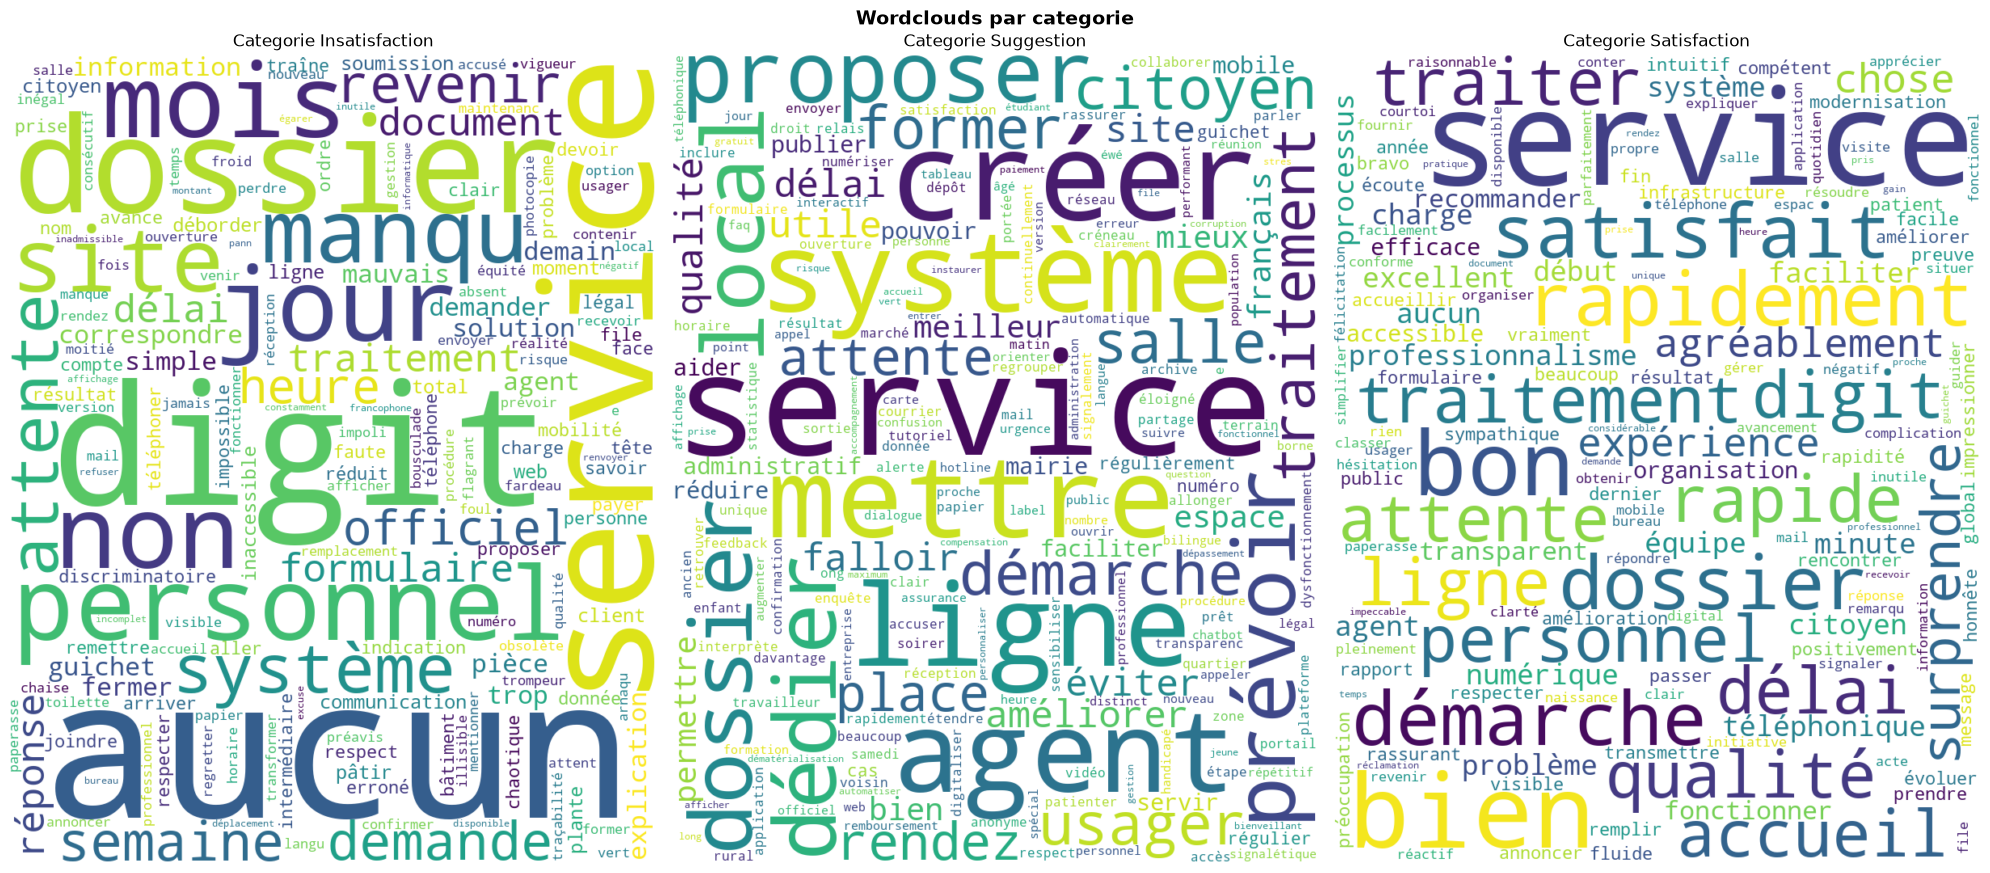

In [46]:
fig1, ax1= plt.subplots(1, 3, figsize=(20, 9))

fig1.suptitle("Wordclouds par categorie", fontweight="bold", fontsize=14)

for i, cat in enumerate(UNIQUES):
    words= data[data[TARGET] == cat]["tokens"].values.sum()
    text= " ".join(words)

    cloud= WordCloud(
        width= 800,
        height= 1000,
        background_color="white",
        colormap="viridis"
    ).generate(text)

    ax1[i].imshow(cloud, interpolation='bilinear')
    ax1[i].axis("off")
    ax1[i].set_title(f"Categorie {cat}")

plt.tight_layout()
plt.show()

#### Résultat des nuages de mots

Le nuage d'Insatisfaction fait ressortir notamment `mois`, `dossier`, `attente`, `service` et `personnel`, ce qui correspond aux plaintes sur les délais et le fonctionnement administratif. Le nuage de Suggestion met en avant `proposer`, `former`, `service`, `système` et `améliorer`, tandis que Satisfaction fait apparaître `service`, `bien`, `rapidement`, `personnel` et `dossier`.

Le recouvrement autour de `service`, `dossier` et `personnel` montre que la fréquence seule ne suffit pas à séparer les classes. Il faut donc compléter cette lecture par les fréquences chiffrées et la pondération TF-IDF.

#### Fréquences lexicales par catégorie

Nous allons maintenant afficher les quinze tokens les plus fréquents dans chaque catégorie. L'objectif est de distinguer les mots communs du corpus des indices lexicaux susceptibles d'aider la classification.

In [47]:
print("="*50)
print("Les 15 termes les plus fréquents par càtégorie")
print("="*50)


for cat in UNIQUES:
    print()
    print(f"Catégorie {cat}")

    words= data[data[TARGET] == cat]["tokens"].values.sum()

    counts= dict(Counter(words))
    firsts= list(dict(sorted(counts.items(), key= lambda item: item[1], reverse=True)).keys())[:15]

    for i, word in enumerate(firsts, 1):
        print(f"\t{i}. {word} ({counts[word]} occurences)")

Les 15 termes les plus fréquents par càtégorie

Catégorie Insatisfaction
	1. aucun (10 occurences)
	2. digit (7 occurences)
	3. service (6 occurences)
	4. dossier (6 occurences)
	5. personnel (4 occurences)
	6. jour (4 occurences)
	7. mois (4 occurences)
	8. non (4 occurences)
	9. manqu (3 occurences)
	10. site (3 occurences)
	11. système (3 occurences)
	12. attente (3 occurences)
	13. semaine (3 occurences)
	14. demande (3 occurences)
	15. revenir (3 occurences)

Catégorie Suggestion
	1. service (8 occurences)
	2. créer (6 occurences)
	3. ligne (5 occurences)
	4. agent (5 occurences)
	5. système (5 occurences)
	6. mettre (5 occurences)
	7. proposer (4 occurences)
	8. prévoir (4 occurences)
	9. dossier (4 occurences)
	10. dédier (4 occurences)
	11. local (4 occurences)
	12. démarche (3 occurences)
	13. traitement (3 occurences)
	14. citoyen (3 occurences)
	15. usager (3 occurences)

Catégorie Satisfaction
	1. service (15 occurences)
	2. bien (8 occurences)
	3. bon (6 occurences)
	4. sa

#### Résultats des fréquences lexicales

Le terme `service` est le plus fréquent dans Satisfaction avec **15 occurrences**, et apparaît aussi dans Insatisfaction (**6**) et Suggestion (**8**) : il décrit le domaine mais ne suffit pas à prédire la classe.

Insatisfaction se distingue davantage par `aucun` (**10**), `digit` (**7**), `dossier` et `service` (**6** chacun), ainsi que par le vocabulaire de l'attente et du manque. Suggestion est marquée par `créer` (**6**), `ligne`, `agent`, `système` et `mettre` (**5 chacun**). Satisfaction est associée à `bien` (**8**), `bon` (**6**), `satisfait` et `rapidement` (**4 chacun**).

Ces résultats montrent à la fois des indices de catégorie et un vocabulaire partagé. La pondération TF-IDF est donc pertinente pour réduire le poids des termes généraux comme `service` et valoriser les termes plus spécifiques.

## Partie 2 - Modélisation et évaluation

Cette partie répond au deuxième volet du sujet : convertir les textes en variables numériques, entraîner au moins deux algorithmes différents et comparer leurs performances.

Trois modèles sont étudiés pour obtenir des points de comparaison complémentaires :

- **Naïve Bayes**, baseline probabiliste simple et souvent efficace sur les textes courts ;
- **SVM linéaire**, modèle adapté aux espaces TF-IDF de grande dimension ;
- **Random Forest**, approche fondée sur des arbres qui fournit une comparaison avec une famille de modèles différente.

L'évaluation repose sur un jeu de test séparé avant l'apprentissage. Les métriques doivent être lues ensemble : l'accuracy mesure la performance globale, le F1-score macro vérifie l'équilibre entre catégories et les matrices de confusion montrent la nature des erreurs.

### Taille du vocabulaire après nettoyage

Nous allons compter les tokens distincts conservés après le prétraitement. Cette mesure permettra de comparer la richesse du vocabulaire au nombre limité d'observations disponibles avant de construire les vecteurs TF-IDF.

In [48]:
print(len(set(data["tokens"].values.sum())))

414


### Résultat de la taille du vocabulaire

Le prétraitement conserve **414 tokens distincts** pour 150 commentaires. Cette richesse lexicale est importante au regard du nombre d'observations : La matrice TF-IDF sera nécessairement creuse et les scores devront être interprétés avec prudence pour éviter de conclure à une généralisation robuste sur la seule base de 30 exemples de test.

### Séparation entraînement / test

Nous allons réserver 80 % des commentaires à l'apprentissage et 20 % à l'évaluation. La stratification et `SEED=10` doivent conserver les proportions des catégories et rendre le découpage reproductible.

In [49]:
X, y= data["texte_propre"], data[TARGET]
SEED=10

X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, test_size=0.2, random_state=SEED)

print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")
print(f"Shape y_train : {y_train.shape}")
print(f"Shape y_test : {y_test.shape}")

Shape X_train : (120,)
Shape X_test : (30,)
Shape y_train : (120,)
Shape y_test : (30,)


### Résultat de la séparation entraînement / test

Le découpage produit **120 commentaires pour l'entraînement** et **30 pour le test**, soit exactement 80 % et 20 %. Chaque classe contribue 40 exemples à l'entraînement et 10 au test grâce à la stratification, ce qui rend la comparaison des modèles équitable sur ce split.

### Vectorisation TF-IDF

Nous allons ajuster le vectoriseur sur les 120 commentaires d'entraînement, puis transformer séparément les 30 commentaires de test. Cette méthode évite d'utiliser le vocabulaire du test pour apprendre les poids et produit une représentation directement exploitable par les trois classifieurs.

In [50]:
tfidf= TfidfVectorizer()

X_train_vec= tfidf.fit_transform(X_train)
X_test_vec= tfidf.transform(X_test)

print(f"Dimensions de X_train_vec (vecteurs) : {X_train_vec.shape[0]} lignes (retours) x {X_train_vec.shape[1]} colonnes (features TF-IDF)")
print(f"Dimensions de X_test_vec (vecteurs) : {X_test_vec.shape[0]} lignes (retours) x {X_test_vec.shape[1]} colonnes (features TF-IDF)")

Dimensions de X_train_vec (vecteurs) : 120 lignes (retours) x 364 colonnes (features TF-IDF)
Dimensions de X_test_vec (vecteurs) : 30 lignes (retours) x 364 colonnes (features TF-IDF)


### Résultat de la vectorisation TF-IDF

Les 120 textes d'entraînement sont représentés par **364 features**, et les 30 textes de test utilisent exactement les mêmes 364 colonnes. Le vocabulaire passe donc de 414 tokens distincts après nettoyage à 364 features effectivement retenues par le vectoriseur, ce qui confirme une représentation de grande dimension pour un corpus réduit.

### Modèle 1 - Naïve Bayes

Naïve Bayes constitue une baseline adaptée à la classification de textes représentés par des fréquences ou des poids TF-IDF. Il estime la probabilité de chaque catégorie à partir des termes observés et suppose une indépendance conditionnelle entre les caractéristiques.

Cette hypothèse est simplificatrice, car les mots d'un commentaire ne sont pas réellement indépendants. Elle reste néanmoins utile pour obtenir une référence rapide et interprétable. Le paramètre `alpha=1.0` applique un lissage de Laplace afin d'éviter des probabilités nulles pour les termes absents de certaines catégories.

In [51]:
# Entrainement
nb = MultinomialNB(alpha=1.0)  # alpha=1.0 : lissage de Laplace standard
nb.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[40.,40.,40.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.1,-1.1,-1.1]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U14](3,)","['Insatisfaction','Satisfaction','Suggestion']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 364)","[[0.44,0. ,0.49,...,0. ,0. ,0. ], [0. ,0.48,1.24,...,0. ,0. ,0.43], [0. ,0. ,0.36,...,0.45,0.83,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 364)","[[-5.75,-6.11,-5.72,...,-6.11,-6.11,-6.11], [-6.11,-5.72,-5.3 ,...,-6.11,-6.11,-5.75], [-6.13,-6.13,-5.82,...,-5.76,-5.53,-6.13]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,364


In [52]:
# Prediction
y_pred_nb = nb.predict(X_test_vec)

In [53]:
# Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_score_nb = f1_score(y_test, y_pred_nb, average="macro")

print(f'Accuracy Naive Bayes : {accuracy_nb*100:.2f}%')
print(f'F1 score Macro Naive Bayes : {f1_score_nb*100:.2f}%')
print()
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes : 56.67%
F1 score Macro Naive Bayes : 57.01%

                precision    recall  f1-score   support

Insatisfaction       0.50      0.40      0.44        10
  Satisfaction       0.47      0.70      0.56        10
    Suggestion       0.86      0.60      0.71        10

      accuracy                           0.57        30
     macro avg       0.61      0.57      0.57        30
  weighted avg       0.61      0.57      0.57        30



#### Résultats de Naïve Bayes

Naïve Bayes obtient **56,67 % d'accuracy** et **57,01 % de F1-score macro** sur les 30 commentaires de test. Le modèle reconnaît mieux Satisfaction (**rappel : 0,70**) et Suggestion (**rappel : 0,60**) qu'Insatisfaction (**rappel : 0,40**).

La précision de Suggestion atteint **0,86**, alors que celle d'Insatisfaction est de **0,50**. Naïve Bayes produit donc des prédictions assez fiables lorsqu'il annonce Suggestion, mais il manque plusieurs commentaires réellement insatisfaits. Ces résultats constituent la référence de comparaison pour les modèles suivants.

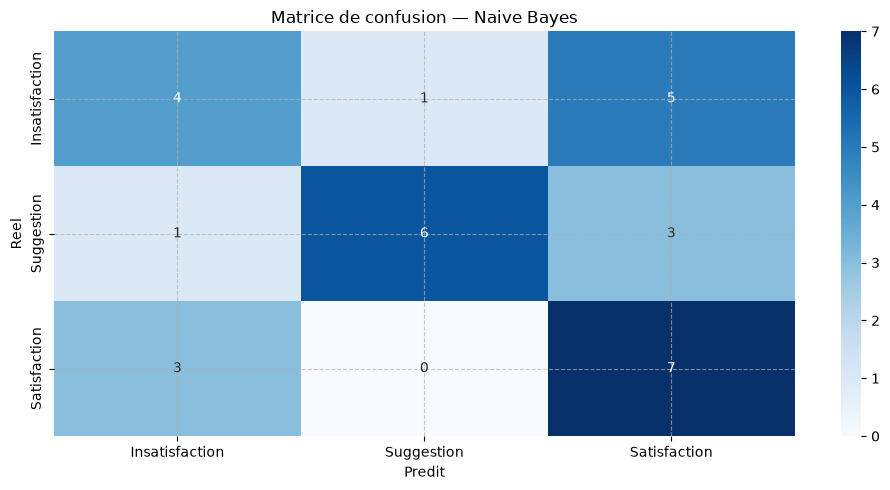

In [61]:
# Matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=UNIQUES)

plt.figure(figsize=(10, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIQUES,
            yticklabels=UNIQUES)
plt.title('Matrice de confusion — Naive Bayes')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.grid(True, axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### Résultat de la matrice de confusion de Naïve Bayes

La diagonale contient **4 Insatisfactions**, **6 Suggestions** et **7 Satisfactions** correctement reconnues. La confusion principale concerne **5 Insatisfactions classées comme Satisfaction** ; Elle explique le rappel faible de la classe Insatisfaction.

Le modèle confond également **3 Suggestions avec Satisfaction** et **3 Satisfactions avec Insatisfaction**. Ces erreurs sont cohérentes avec le vocabulaire partagé autour de `service`, `dossier` et `personnel`, ainsi qu'avec les commentaires courts où le contexte négatif ou positif est peu marqué.

### Modèle 2 - SVM linéaire

Le SVM linéaire cherche une frontière séparant les catégories dans l'espace TF-IDF. Il est particulièrement adapté aux représentations textuelles, souvent de grande dimension et peu denses, et constitue généralement un candidat solide pour un corpus court.

La comparaison avec Naïve Bayes permet de vérifier si une frontière discriminante linéaire exploite mieux les indices lexicaux que l'approche probabiliste.

In [55]:
# Entrainement
svm = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
svm.fit(X_train_vec, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",10
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",2000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are su

In [56]:
# Prediction et evaluation
y_pred_svm = svm.predict(X_test_vec)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_score_svm = f1_score(y_test, y_pred_svm, average="macro")

print(f'Accuracy SVM : {accuracy_svm*100:.2f}%')
print(f'F1 score Macro SVM : {f1_score_svm*100:.2f}%')
print()
print(classification_report(y_test, y_pred_svm))

Accuracy SVM : 66.67%
F1 score Macro SVM : 66.07%

                precision    recall  f1-score   support

Insatisfaction       0.67      0.40      0.50        10
  Satisfaction       0.53      0.80      0.64        10
    Suggestion       0.89      0.80      0.84        10

      accuracy                           0.67        30
     macro avg       0.70      0.67      0.66        30
  weighted avg       0.70      0.67      0.66        30



#### Résultats du SVM

Le SVM obtient **66,67 % d'accuracy** et **66,07 % de F1-score macro**, soit environ 10 points de plus que Naïve Bayes sur les deux indicateurs. Il améliore le rappel de Satisfaction à **0,80** et celui de Suggestion à **0,80**, tandis que le rappel d'Insatisfaction reste limité à **0,40**.

Le SVM est donc le meilleur modèle sur ce split, mais sa performance reste inégale : Il reconnaît correctement 8 Suggestions et 8 Satisfactions sur 10, contre seulement 4 Insatisfactions sur 10.

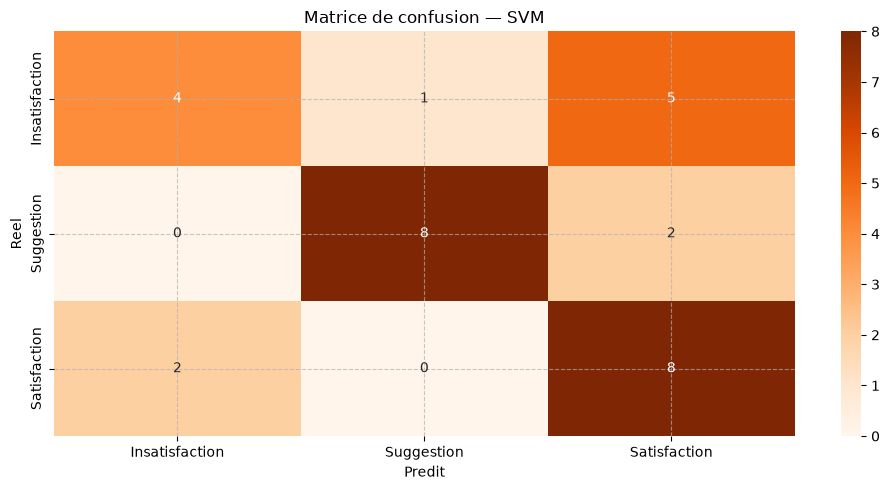

In [62]:
# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=UNIQUES)

plt.figure(figsize=(10, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=UNIQUES,
            yticklabels=UNIQUES)
plt.title('Matrice de confusion — SVM')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.grid(True, axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### Résultat de la matrice de confusion du SVM

Le SVM classe correctement **4 Insatisfactions**, **8 Suggestions** et **8 Satisfactions**. Comme pour Naïve Bayes, **5 Insatisfactions sont prédites comme Satisfaction**, ce qui montre que la difficulté liée à cette frontière sémantique n'est pas propre au modèle probabiliste.

Le SVM ne confond aucune Suggestion avec Insatisfaction et aucune Satisfaction avec Suggestion sur ce split. Il réduit donc certaines confusions croisées, mais ne résout pas le problème principal de séparation entre retours positifs et plaintes.

### Modèle 3 - Random Forest

Random Forest combine de nombreux arbres de décision entraînés sur des sous-échantillons différents. Cette approche fournit un point de comparaison avec une famille de modèles non linéaire, même si les espaces TF-IDF très creux sont souvent plus naturellement exploités par des modèles linéaires.

Le paramètre `n_estimators=500` augmente le nombre d'arbres et peut stabiliser les prédictions, mais il ne compense pas la petite taille du dataset. Les résultats doivent donc rester associés à une discussion sur le risque de surapprentissage et la variabilité du split.

In [58]:
# Entrainement
rf = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)
rf.fit(X_train_vec, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [59]:
# Prediction et evaluation
y_pred_rf = rf.predict(X_test_vec)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf, average="macro")

print(f'Accuracy Random Forest : {accuracy_rf*100:.2f}%')
print(f'F1 score Macro Random Forest : {f1_score_rf*100:.2f}%')
print()
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest : 50.00%
F1 score Macro Random Forest : 49.56%

                precision    recall  f1-score   support

Insatisfaction       0.38      0.30      0.33        10
  Satisfaction       0.46      0.60      0.52        10
    Suggestion       0.67      0.60      0.63        10

      accuracy                           0.50        30
     macro avg       0.50      0.50      0.50        30
  weighted avg       0.50      0.50      0.50        30



#### Résultats de Random Forest

Random Forest obtient **50,00 % d'accuracy** et **49,56 % de F1-score macro**, soit le moins bon résultat des trois modèles sur ce split. Son rappel est de **0,30 pour Insatisfaction**, **0,60 pour Satisfaction** et **0,60 pour Suggestion**.

Cette performance montre que l'ensemble de 500 arbres n'exploite pas aussi efficacement que le SVM la représentation TF-IDF très creuse. Le résultat ne permet pas de conclure que Random Forest est toujours inférieur, mais il n'est pas le meilleur choix dans cette configuration.

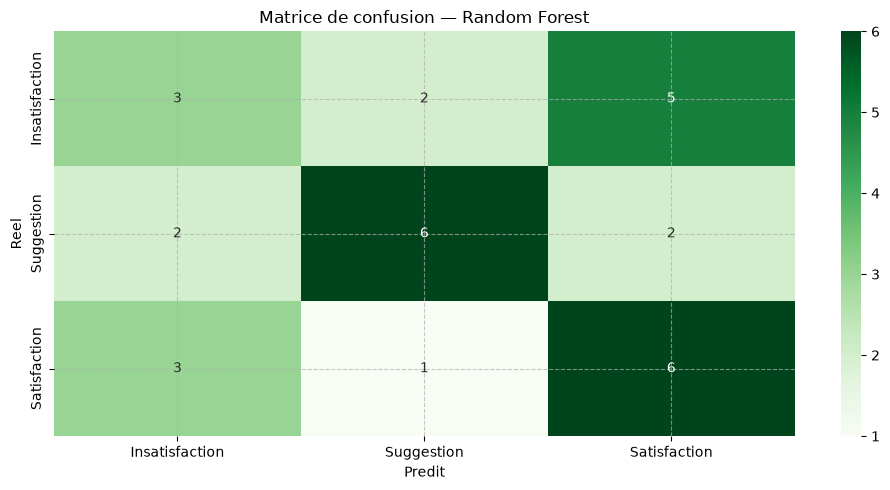

In [63]:
# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=UNIQUES)

plt.figure(figsize=(10, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=UNIQUES,
            yticklabels=UNIQUES)
plt.title('Matrice de confusion — Random Forest')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.grid(True, axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### Résultat de la matrice de confusion de Random Forest

Random Forest reconnaît correctement **3 Insatisfactions**, **6 Suggestions** et **6 Satisfactions**. Il confond **5 Insatisfactions avec Satisfaction**, comme les deux autres modèles, et produit en plus **3 Suggestions classées comme Insatisfaction** ainsi que **3 Satisfactions classées comme Insatisfaction**.

Les trois matrices montrent donc une difficulté persistante autour d'Insatisfaction. Le SVM reste préférable sur les métriques globales, mais l'analyse de plusieurs exemples mal classés est nécessaire avant toute conclusion définitive, car un seul split de 30 commentaires peut amplifier les écarts.

## Conclusion de l'analyse

### Comparaison des modèles

| Modèle | Accuracy | F1-score macro | Observation principale |
|---|---:|---:|---|
| Naïve Bayes | 56,67 % | 57,01 % | Meilleur rappel pour Satisfaction parmi les deux modèles de référence, mais 5 Insatisfactions classées comme Satisfaction. |
| SVM linéaire | **66,67 %** | **66,07 %** | Meilleur compromis global ; 8 Suggestions et 8 Satisfactions correctement reconnues. |
| Random Forest | 50,00 % | 49,56 % | Résultat le plus faible ; davantage de confusions vers Insatisfaction. |

Sur le split stratifié de 30 commentaires, le **SVM linéaire est le modèle à retenir**. Sa supériorité reste relative : Il ne reconnaît que 4 Insatisfactions sur 10, et les trois modèles classent 5 Insatisfactions comme Satisfaction. Cette erreur récurrente doit être étudiée sur les textes concernés, car elle peut venir d'un vocabulaire partagé, d'une négation mal représentée, d'un commentaire trop court ou d'une formulation multilingue.

### Limites de l'approche

- Le dataset ne contient que 150 commentaires et le test ne compte que 30 observations : Les scores peuvent varier fortement selon la séparation.
- Un seul split est utilisé : Une validation croisée stratifiée donnerait une estimation plus robuste.
- La représentation TF-IDF exploite surtout la présence des mots et représente mal la synonymie, l'ordre des mots et le contexte.
- Le modèle SpaCy est principalement orienté vers le français et le dictionnaire local ne couvre que quelques termes explicitement connus.
- Les catégories peuvent être sémantiquement proches, notamment lorsqu'une plainte contient aussi une proposition d'amélioration.

### Pistes d'amélioration

1. **Analyser les erreurs réelles** : Relever trois à cinq commentaires mal classés, comparer leur catégorie réelle et leur prédiction, puis relier chaque erreur à un indice textuel précis.
2. **Renforcer la gestion du multilinguisme** : Enrichir le lexique éwé/mina avec des traductions validées, des variantes orthographiques et, si possible, une ressource bilingue.
3. **Tester des représentations complémentaires** : Comparer TF-IDF à des n-grammes et à des embeddings multilingues comme CamemBERT, mBERT ou XLM-R.
4. **Fiabiliser l'évaluation** : Utiliser une validation croisée stratifiée et une recherche d'hyperparamètres avant de recommander un modèle pour de nouveaux retours citoyens.
5. **Étendre le corpus** : Ajouter des commentaires annotés et faire vérifier les cas ambigus par plusieurs annotateurs.